In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA, FastICA
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import power_transform


#import lissa as li

In [3]:
n = 500
tf = 10
t = np.linspace(0,tf,n)

In [4]:
window = np.exp((-(t-tf/2)*(t-tf/2))/0.3)

X = np.array(
    [
        np.sin(40*t)*window,
        np.sin(10*t+np.pi/4)*window,
        np.sin(5*t*t),
        np.ones(n)*window
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q



S = pd.DataFrame(X.T@Q,columns=["new 0","new 1","new 2","new 3"])
Sn = (S+noise.T)
Z = Sn.ewm(alpha=0.8).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

model = PCA(n_components=4)
recover = model.fit_transform(Z)
model.components_

array([[ 0.67800899,  0.32406132,  0.09388409,  0.65304965],
       [ 0.71146315, -0.505997  , -0.1378268 , -0.46775099],
       [ 0.1584198 ,  0.52291707,  0.65772442, -0.51851663],
       [-0.09501131, -0.60457343,  0.73456664,  0.29304551]])

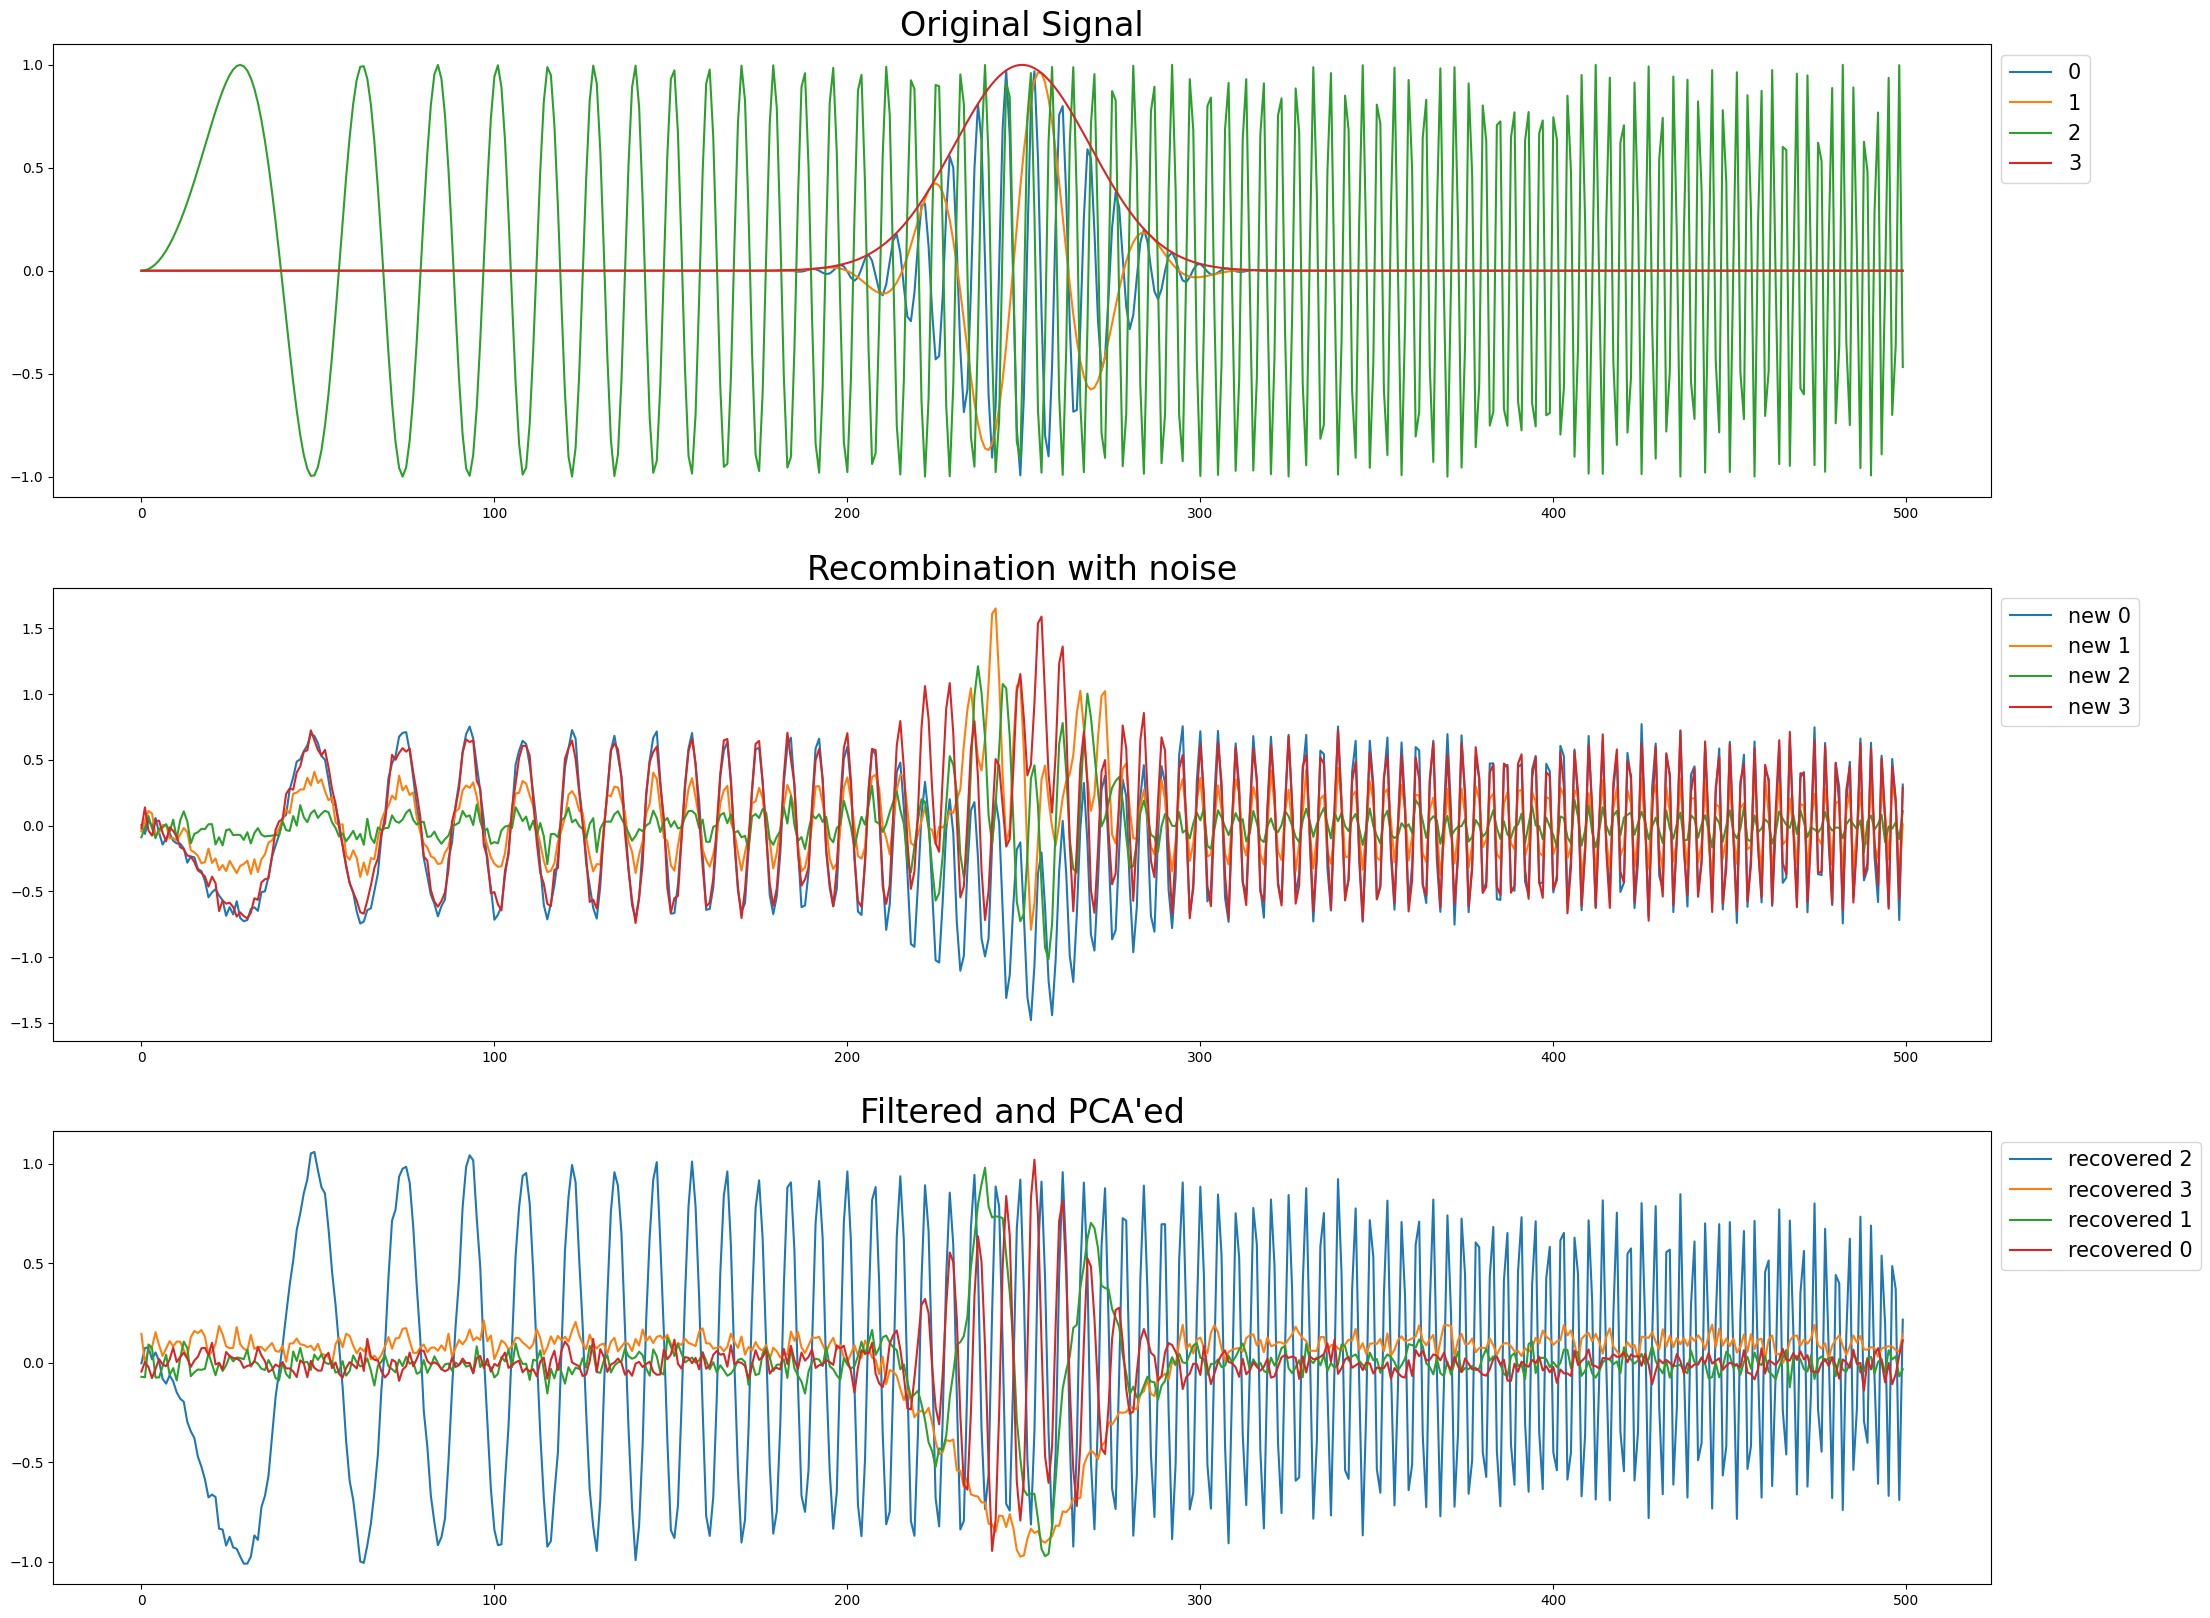

In [5]:
fig, axs = plt.subplots(3,1)
plt.rcParams.update({'font.size': 20})

pd.DataFrame(X.T).plot(ax=axs[0])

Sn.plot(ax=axs[1],figsize=(25,20))



recover = pd.DataFrame(recover,columns=["recovered 2","recovered 3","recovered 1","recovered 0"])

recover.plot(ax=axs[2])

axs[0].set_title("Original Signal")
axs[1].set_title("Recombination with noise")
axs[2].set_title("Filtered and PCA'ed")




axs[0].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[2].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)




array([[<Axes: title={'center': 'recovered 2'}>,
        <Axes: title={'center': 'recovered 3'}>],
       [<Axes: title={'center': 'recovered 1'}>,
        <Axes: title={'center': 'recovered 0'}>]], dtype=object)

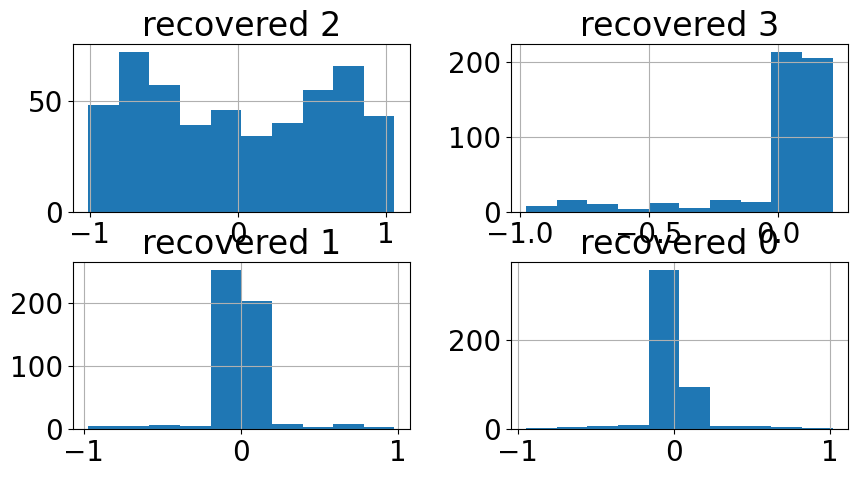

In [6]:
recover.hist(figsize=(10,5))

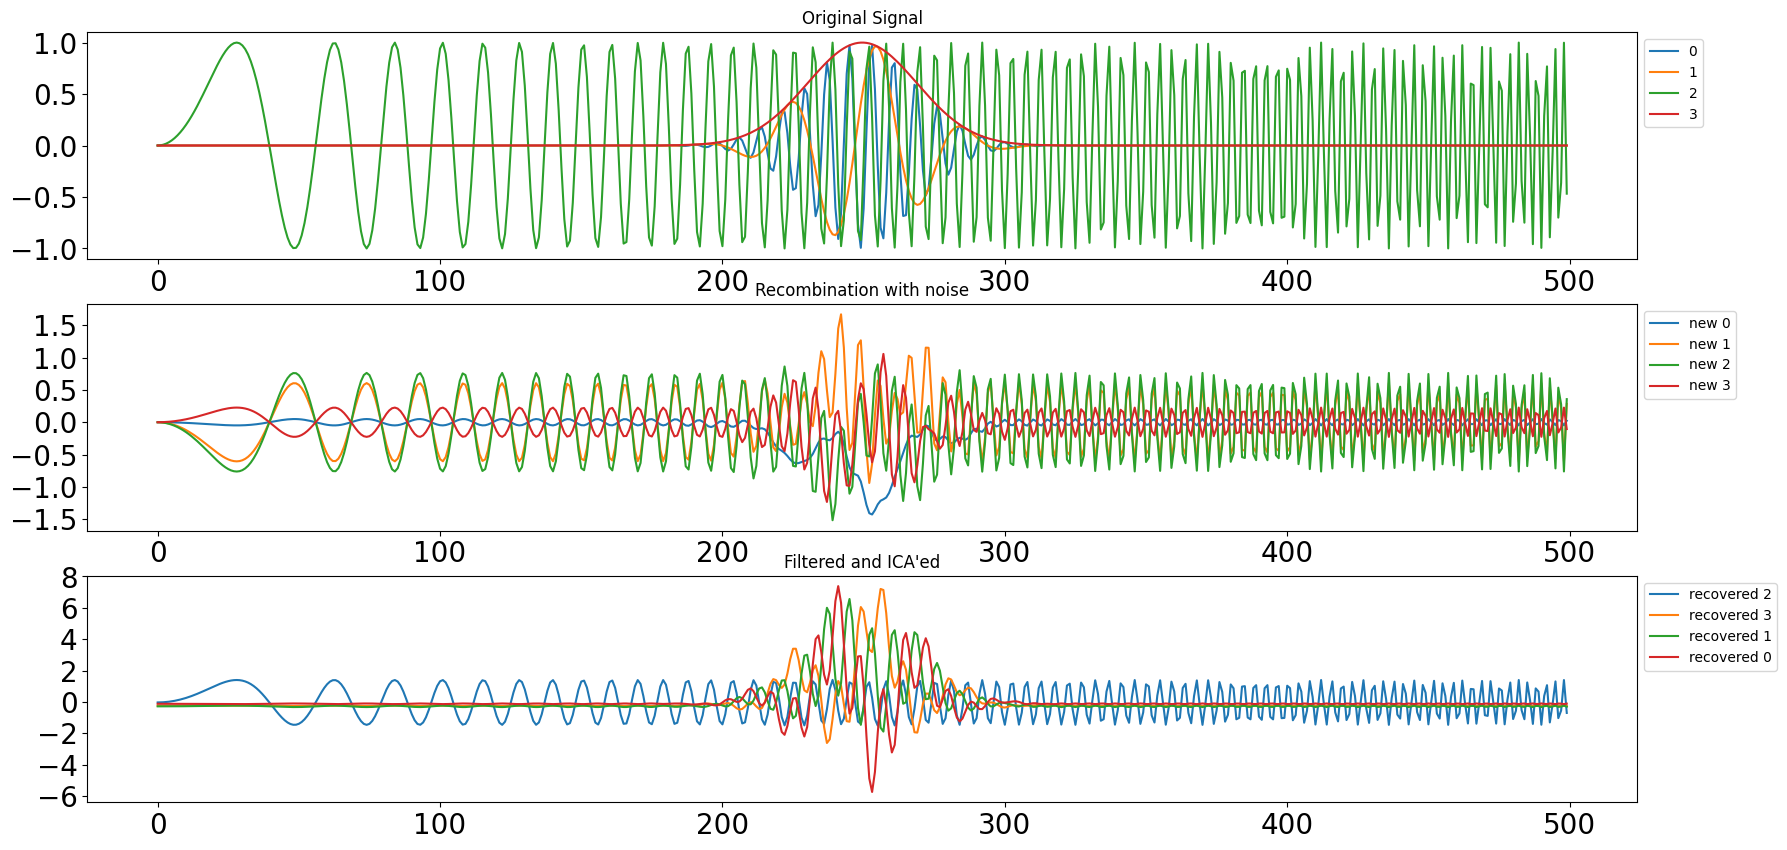

In [7]:
window = np.exp((-(t-tf/2)*(t-tf/2))/0.3)

X = np.array(
    [
        np.sin(40*t)*window,
        np.sin(10*t+np.pi/4)*window,
        np.sin(5*t*t),
        np.ones(n)*window
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q



S = pd.DataFrame(X.T@Q,columns=["new 0","new 1","new 2","new 3"])
Sn = (S)
Z = Sn#.ewm(alpha=0.8).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

model = PCA(n_components=4)
recover = model.fit_transform(Z)
model.components_


icamodel = FastICA(n_components=4)
recover = icamodel.fit_transform(Z)

fig, axs = plt.subplots(3,1)
plt.rcParams.update({'font.size': 10})

pd.DataFrame(X.T).plot(ax=axs[0])

Sn.plot(ax=axs[1],figsize=(20,10))



recover = pd.DataFrame(recover,columns=["recovered 2","recovered 3","recovered 1","recovered 0"])

recover.plot(ax=axs[2])

axs[0].set_title("Original Signal")
axs[1].set_title("Recombination with noise")
axs[2].set_title("Filtered and ICA'ed")




axs[0].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[2].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)




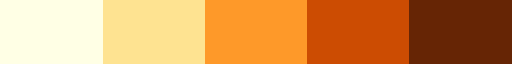

In [ ]:
# Exemplo de estados ao longo do tempo
n = 4
states = range(0,n+1)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('YlOrBr', num_states)  # Escolhe um colormap com num_states cores

cmap

In [ ]:
squared = recover.pow(2).sum(axis=1).pow(1/2)

model = GaussianHMM(n_components=n,covariance_type="full",random_state=np.random.seed(19971215))
model.fit(squared.to_numpy().reshape(-1,1))

states = model.predict(squared.to_numpy().reshape(-1,1))

final = pd.DataFrame(np.array([squared, states]).T,columns=["Square","STS"])


Text(0.5, 1.0, 'Hidden Markov applied to norm-2 PCA components')

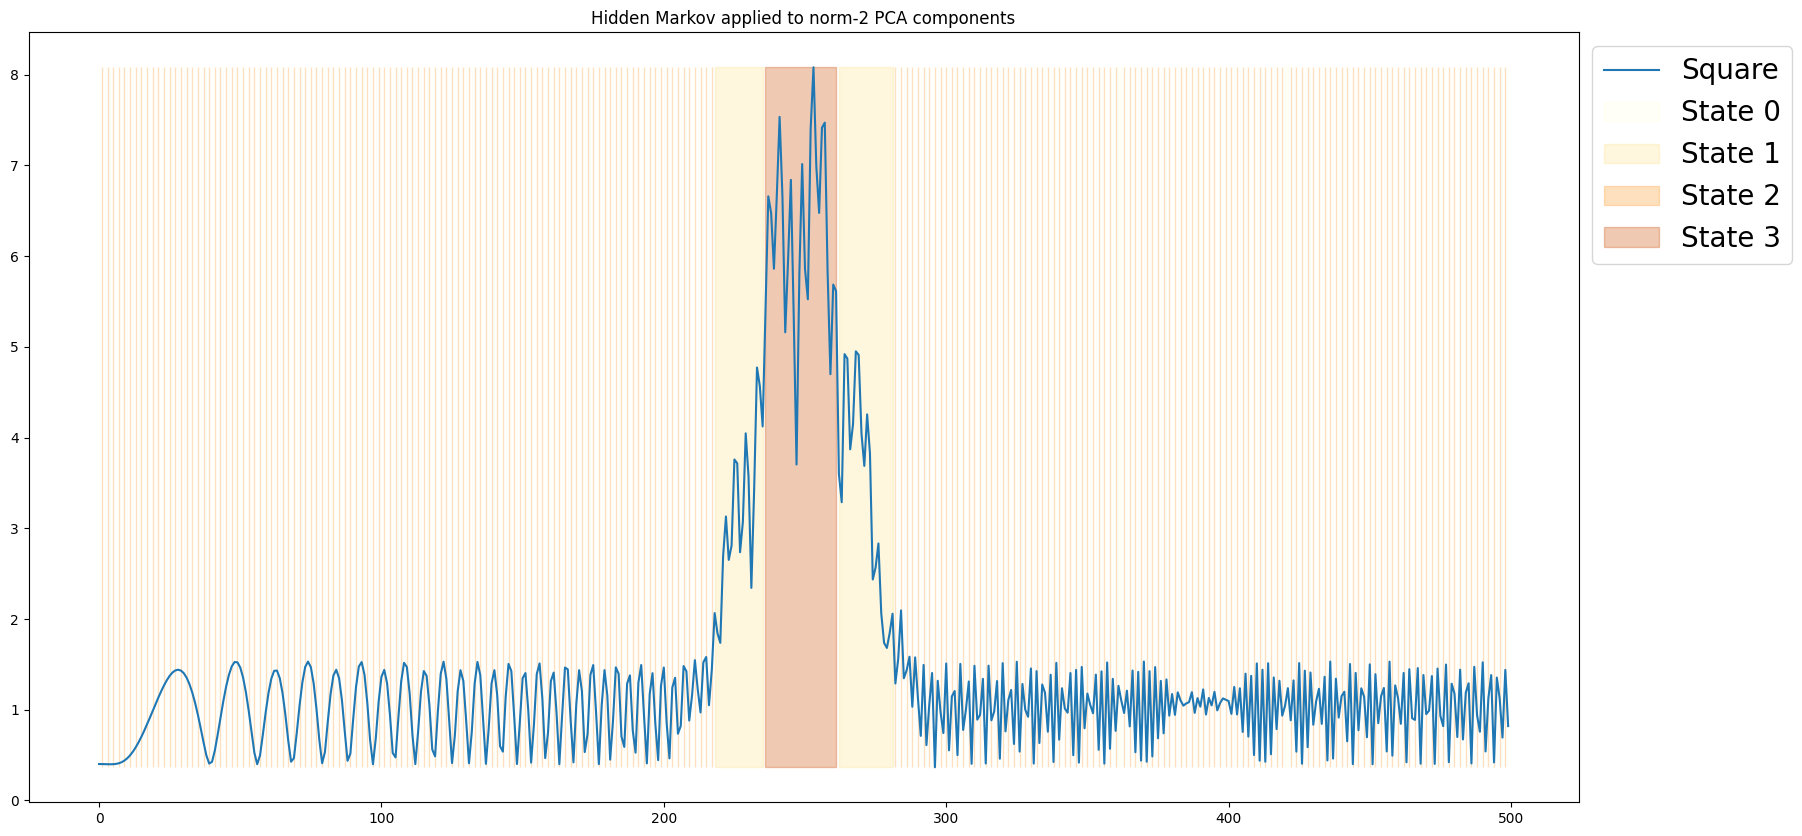

In [ ]:
fig,axs = plt.subplots(1,1)
final["Square"].plot(ax=axs,figsize=(20,10))


for state in range(0,n):
            color = cmap(state)  # Pega uma cor automática para cada estado
            axs.fill_between(final.index,np.min(squared), np.max(squared), where=(final["STS"] == state), 
                            color=color, alpha=0.3, label=f"State {state}")

            axs.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=20)

plt.title("Hidden Markov applied to norm-2 PCA components")


In [ ]:
print(model.get_stationary_distribution())

[0.18444208 0.43817751 0.29384103 0.08353938]


The Autocorrelation plot for the data is:


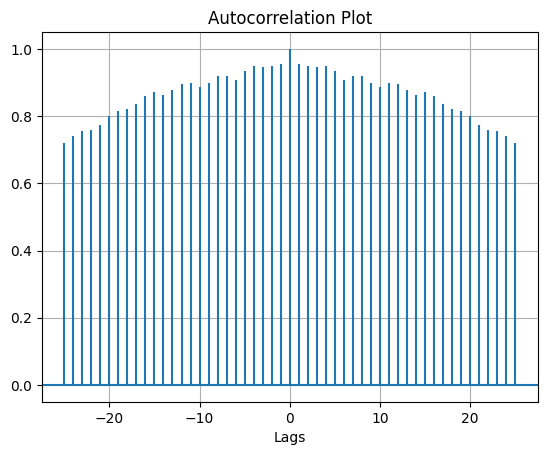

In [ ]:
# Importing the libraries.
import matplotlib.pyplot as plt 
import numpy as np 

# Data for which we plot Autocorrelation.
data =final["Square"]

# Adding plot title.
plt.title("Autocorrelation Plot") 

# Providing x-axis name.
plt.xlabel("Lags") 

# Plotting the Autocorrelation plot.
plt.acorr(data, maxlags = 25) 

# Displaying the plot.
print("The Autocorrelation plot for the data is:")
plt.grid(True)

plt.show() 


In [ ]:
k = 5

dataPD = pd.DataFrame()
for i in range(0,k):
    dataPD[f"Square_{i}"] = data.shift(i)

In [ ]:
data2reg = dataPD.dropna(axis=0).shift(-1).dropna()
y = data.shift(-k).dropna()

In [ ]:
A = data2reg.T@data2reg
b = data2reg.T.to_numpy()@y

In [ ]:
np.linalg.solve(A,b)

array([ 1.00000000e+00,  7.99963533e-15, -7.13339949e-15, -1.17559439e-15,
        9.98559715e-16])